In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("../data/creditcard.csv")      #Load the dataset

In [7]:
df.head()       #Check Dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape        #Check the number of rows and columns in the dataset

(284807, 31)

In [9]:
df.isnull().sum()     #Check for null values in the dataset

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df['Class'].value_counts()     #Check the distribution of normal and fraudulent transactions

Class
0    284315
1       492
Name: count, dtype: int64

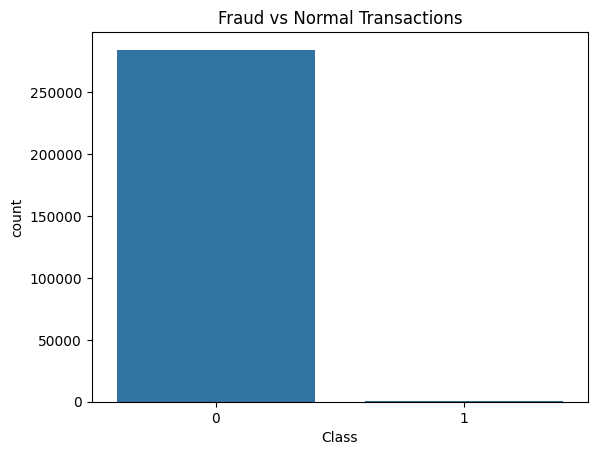

In [11]:
sns.countplot(x='Class', data=df)     #Visualize the distribution of normal and fraudulent transactions
plt.title('Fraud vs Normal Transactions')
plt.show()

In [12]:
X = df.drop('Class', axis=1)     #Separate features and target variable
y = df['Class']

In [13]:
scaler = StandardScaler()     #Scale the features
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y      #stratify = y because fraud cases are very few so to keep the class balacnce equal in train set and test set.
)

In [15]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)     #Train Logistic Regression model

LogisticRegression()

In [16]:
lr_predictions = lr_model.predict(X_test)    #Predict on test set using Logistic Regression model

In [17]:
print("Accuracy", accuracy_score(y_test, lr_predictions))
print("Precision", precision_score(y_test, lr_predictions))
print("Recall", recall_score(y_test, lr_predictions))
print("F1 Score", f1_score(y_test, lr_predictions))

Accuracy 0.9991573329588147
Precision 0.7604166666666666
Recall 0.7448979591836735
F1 Score 0.7525773195876289


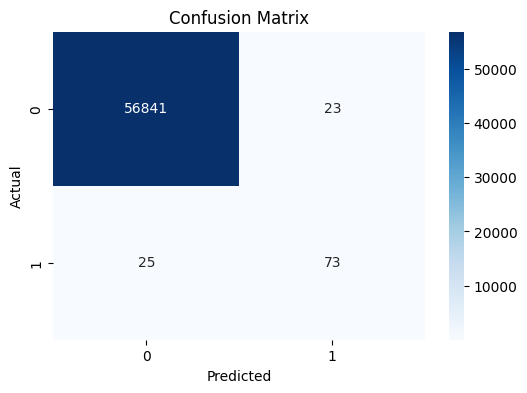

In [18]:
cm = confusion_matrix(y_test, lr_predictions)     #Confusion Matrix

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
    )  
rf_model.fit(X_train, y_train)     #Train Random Forest model

RandomForestClassifier(random_state=42)

In [22]:
rf_predictions = rf_model.predict(X_test)    #Predict on test set using Random Forest model

In [23]:
print("Accuracy: ", accuracy_score(y_test, rf_predictions))
print("Precision: ", precision_score(y_test, rf_predictions))
print("Recall: ", recall_score(y_test, rf_predictions))
print("F1 Score: ", f1_score(y_test, rf_predictions))

Accuracy:  0.9995962220427653
Precision:  0.9411764705882353
Recall:  0.8163265306122449
F1 Score:  0.8743169398907104


In [24]:
importance = rf_model.feature_importances_     #Feature importance from Random Forest model
feature_impportance = pd.DataFrame({
    'Feature': X.columns,   
    'Importance': importance
})
feature_impportance = feature_impportance.sort_values(
    by='Importance', 
    ascending=False
    )     #Sort features by importance    

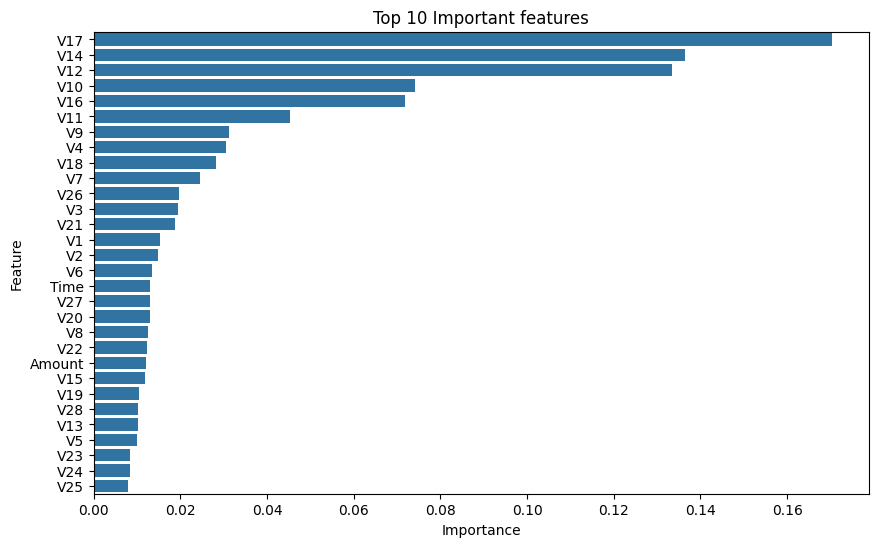

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_impportance
)

plt.title("Top 10 Important features")

plt.show()

In [26]:
import pickle

In [27]:
with open('../models/fraud_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

In [28]:
with open('../models/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)